# Scale-aware segmentation

Sea ice floes span length scales from meters to 10s of kilometers. As such, segmentation methods adapted for the problem of sea ice floe identification require different approaches than typical segmentation analysis.

In [1]:
using Pkg
Pkg.activate("../scripts/calval/")
using IceFloeTracker
using Images

begin
    case_number = "001-" # Note: Hyphen prevents this from matching years, e.g. 201001    
    dataloc = "/Users/dmw/Documents/research/ift_fram_strait_test_cases/data/modis/"
    falsecolor_files = filter(f -> f != ".DS_Store", readdir(joinpath(dataloc, "falsecolor")))
    falsecolor_files = filter(f -> occursin(case_number, f), falsecolor_files)
    truecolor_files = replace.(falsecolor_files, ("falsecolor" => "truecolor"))
    landmask_file = joinpath(dataloc, "landmask.tiff")
    landmask_img = Gray.(load(landmask_file)) .> 0;
    tile_settings = (; rblocks=4, cblocks=2)
    clip=2
end

  Activating project at `~/Documents/research/calval_tgrs/scripts/calval`


2

In [3]:
idx = 1
tc_img = RGB.(load(joinpath(dataloc, "truecolor", truecolor_files[idx])))
fc_img = RGB.(load(joinpath(dataloc, "falsecolor", falsecolor_files[idx])));


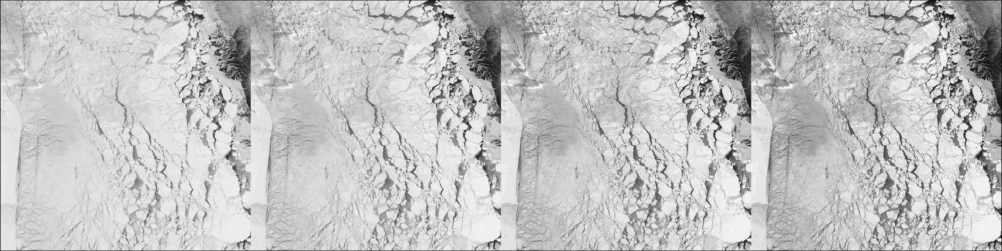

In [4]:
include("../scripts/dev/segmentation.jl")
gray_imgs =
[Preprocess(
    histogram_params=(nbins=128, rblocks=8, cblocks=4, clip=i)
    )(tc_img, landmask_img) for i in 1:4]
tile = (1000:2000, 1500:2500)
mosaicview([img[tile...] for img in gray_imgs]..., nrow=1)

The distinction between ice floes is ambiguous without motion information. In this image, we can see the initial formation of leads, and we can see that one of the larger floes contains numerous fused smaller floes. In this case, the large object near the image center is a large, fused region of pack ice in the process of breaking off and drifting. One interesting question for fracture is whether we can demonstrate that objects such as this fracture through the existing heterogeneities or if the fracture is independent of the structure.

In [5]:
tiles = get_tiles(tc_img; rblocks=4, cblocks=2)
kmeans_seg = kmeans_segmentation.(gray_imgs, [tiles]; k=4);
# mosaicview(view_seg_random.(kmeans_seg)..., nrow=1)

┌ Warning: The clustering cost increased at iteration #9
└ @ Clustering ~/.julia/packages/Clustering/M6mjF/src/kmeans.jl:191


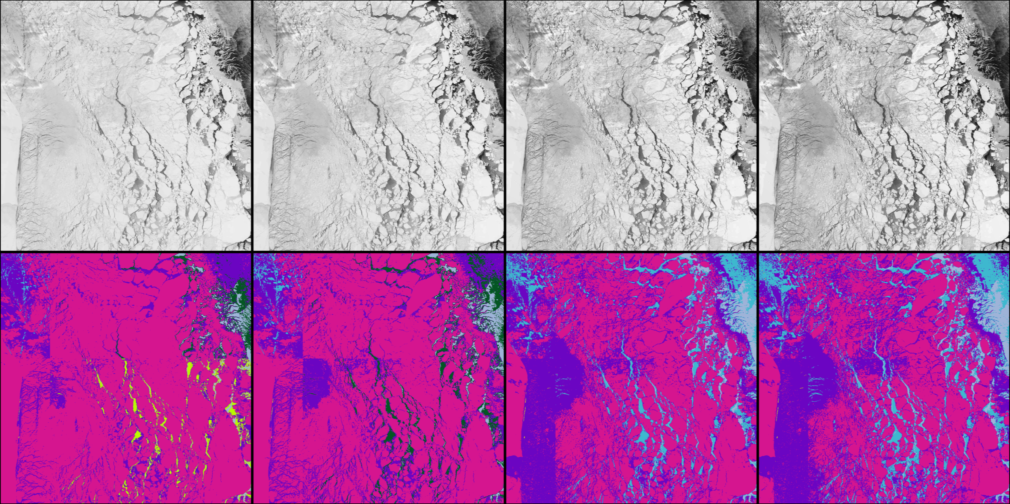

In [6]:
tile = (1000:2000, 1500:2500)
mosaicview(
    mosaicview([img[tile...] for img in gray_imgs]..., nrow=1, npad=10),
    mosaicview((view_seg_random.(kmeans_seg) .|> r -> r[tile...])..., nrow=1, npad=10),
npad=10, nrow=2)

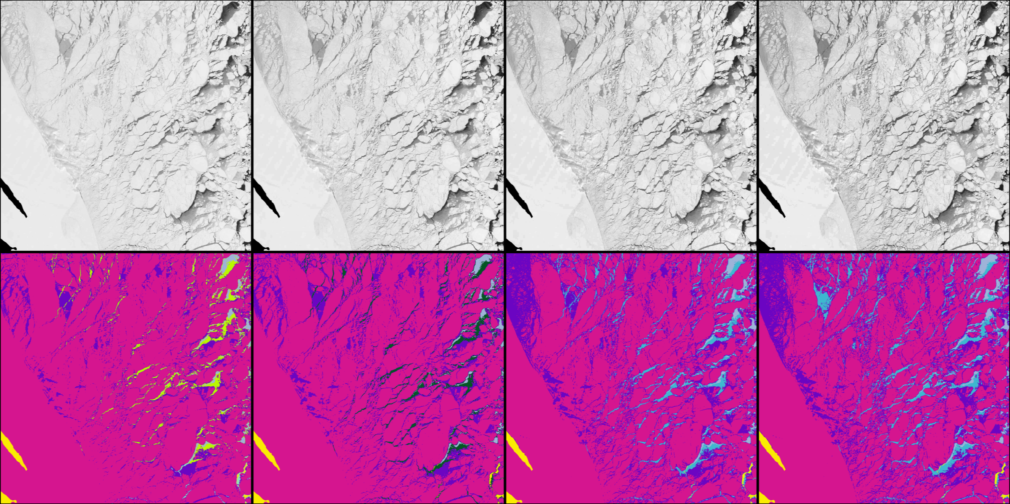

In [7]:
tile = (2000:3000, 1600:2600)
mosaicview(
    mosaicview([img[tile...] for img in gray_imgs]..., nrow=1, npad=10),
    mosaicview((view_seg_random.(kmeans_seg) .|> r -> r[tile...])..., nrow=1, npad=10),
npad=10, nrow=2)

For the floe tracking dataset, we need to be confident that we are 